# Olist Brazilian E-Commerce: data model exploration

This notebook profiles the Olist CSV dataset, proposes primary and foreign-key
relationships, produces a compact entity-relationship (ER) diagram, and offers
optional checks for an equivalent PostgreSQL database.

**Recommended order:** run the setup and data-loading sections first, then the
profiling, relationship, and diagram sections. The PostgreSQL section is optional
and requires a running database that has already been populated.


## 1. Setup

Install the Python packages once per environment. `graphviz` also needs the
Graphviz system application installed so that the `dot` command is available.


In [1]:
# Run this only if the packages are not already installed in the current kernel.
%pip install -q pandas sqlalchemy psycopg2-binary graphviz
%pip install sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path
import os
import sys

import pandas as pd
from graphviz import Digraph
from IPython.display import Image, display

pd.set_option("display.max_columns", 100)

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")


Python executable: /Library/Developer/CommandLineTools/usr/bin/python3
Python version: 3.9.6


## 2. Locate and load the CSV files

The default points to the local KaggleHub cache. Set `OLIST_DATASET_PATH` before
starting Jupyter if the data lives elsewhere. The validation below fails early
with a clear message when the folder is unavailable.


In [5]:
DEFAULT_DATASET_PATH = Path(
    "/Users/ouahibaahmid/.cache/kagglehub/datasets/olistbr/"
    "brazilian-ecommerce/versions/2"
)
DATASET_PATH = Path(os.environ.get("OLIST_DATASET_PATH", DEFAULT_DATASET_PATH))

if not DATASET_PATH.is_dir():
    raise FileNotFoundError(
        f"Dataset directory was not found: {DATASET_PATH}\n"
        "Set the OLIST_DATASET_PATH environment variable to the CSV folder."
    )

csv_paths = sorted(DATASET_PATH.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"No CSV files were found in {DATASET_PATH}")

print(f"Dataset path: {DATASET_PATH}")
print(f"Found {len(csv_paths)} CSV files:")
for path in csv_paths:
    print(f"- {path.name}")


Dataset path: /Users/ouahibaahmid/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
Found 9 CSV files:
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv


In [6]:
# The file stem is retained as the table key so it stays traceable to the source CSV.
tables = {
    path.stem: pd.read_csv(path, low_memory=False)
    for path in csv_paths
}

dataset_summary = pd.DataFrame(
    [
        {"table": name, "rows": len(df), "columns": df.shape[1]}
        for name, df in tables.items()
    ]
).sort_values("table", ignore_index=True)

display(dataset_summary)


,table,rows,columns
0,olist_customers_dataset,99441,5
1,olist_geolocation_dataset,1000163,5
2,olist_order_items_dataset,112650,7
3,olist_order_payments_dataset,103886,5
4,olist_order_reviews_dataset,99224,7
5,olist_orders_dataset,99441,8
6,olist_products_dataset,32951,9
7,olist_sellers_dataset,3095,4
8,product_category_name_translation,71,2


## 3. Profile the source tables

This section gives a compact view of each table's columns, data types, missing
values, and distinct-value counts. It is an exploratory aid; a distinct column is
not automatically a business key without domain validation.


In [7]:
def profile_table(df: pd.DataFrame) -> pd.DataFrame:
    '''Return column-level completeness and cardinality information for one table.'''
    return pd.DataFrame(
        {
            "column": df.columns,
            "dtype": df.dtypes.astype(str).to_numpy(),
            "null_count": df.isna().sum().to_numpy(),
            "null_pct": (df.isna().mean().mul(100).round(2)).to_numpy(),
            "distinct_values": [df[column].nunique(dropna=True) for column in df.columns],
        }
    )


for table_name, df in tables.items():
    print(f"\n{'=' * 90}\n{table_name} — {len(df):,} rows × {df.shape[1]} columns")
    display(profile_table(df))



olist_customers_dataset — 99,441 rows × 5 columns


,column,dtype,null_count,null_pct,distinct_values
0,customer_id,object,0,0.0,99441
1,customer_unique_id,object,0,0.0,96096
2,customer_zip_code_prefix,int64,0,0.0,14994
3,customer_city,object,0,0.0,4119
4,customer_state,object,0,0.0,27



olist_geolocation_dataset — 1,000,163 rows × 5 columns


,column,dtype,null_count,null_pct,distinct_values
0,geolocation_zip_code_prefix,int64,0,0.0,19015
1,geolocation_lat,float64,0,0.0,717363
2,geolocation_lng,float64,0,0.0,717615
3,geolocation_city,object,0,0.0,8011
4,geolocation_state,object,0,0.0,27



olist_order_items_dataset — 112,650 rows × 7 columns


...

,column,dtype,null_count,null_pct,distinct_values
0,product_id,object,0,0.00,32951
1,product_category_name,object,610,1.85,73
2,product_name_lenght,float64,610,1.85,66
3,product_description_lenght,float64,610,1.85,2960
4,product_photos_qty,float64,610,1.85,19
5,product_weight_g,float64,2,0.01,2204
6,product_length_cm,float64,2,0.01,99
7,product_height_cm,float64,2,0.01,102
8,product_width_cm,float64,2,0.01,95



olist_sellers_dataset — 3,095 rows × 4 columns


,column,dtype,null_count,null_pct,distinct_values
0,seller_id,object,0,0.0,3095
1,seller_zip_code_prefix,int64,0,0.0,2246
2,seller_city,object,0,0.0,611
3,seller_state,object,0,0.0,23



product_category_name_translation — 71 rows × 2 columns


,column,dtype,null_count,null_pct,distinct_values
0,product_category_name,object,0,0.0,71
1,product_category_name_english,object,0,0.0,71


In [8]:
# Preview a few records from every source table. These are raw source values.
for table_name, df in tables.items():
    print(f"\n{'=' * 90}\n{table_name}")
    display(df.head())



olist_customers_dataset


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



olist_geolocation_dataset


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



olist_order_items_dataset


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



olist_sellers_dataset


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



product_category_name_translation


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## 4. Identify candidate keys and relationships

A candidate primary key must be non-null and unique in its source table. This is a
useful signal, not a final constraint: a column can be unique in one extract without
being the intended business key. Foreign-key suggestions are discovered by checking
whether a populated column's values are a subset of a candidate key. Review all
suggestions because matching values alone cannot prove business meaning.


In [9]:
def candidate_primary_keys(df: pd.DataFrame) -> list[str]:
    '''Return non-null, single-column unique key candidates.'''
    return [
        column
        for column in df.columns
        if df[column].notna().all() and df[column].is_unique
    ]


candidate_keys = {
    table_name: candidate_primary_keys(df)
    for table_name, df in tables.items()
}

key_candidates = pd.DataFrame(
    [
        {"table": table_name, "candidate_primary_keys": ", ".join(keys) or "—"}
        for table_name, keys in candidate_keys.items()
    ]
).sort_values("table", ignore_index=True)

display(key_candidates)


,table,candidate_primary_keys
0,olist_customers_dataset,customer_id
1,olist_geolocation_dataset,—
2,olist_order_items_dataset,—
3,olist_order_payments_dataset,—
4,olist_order_reviews_dataset,—
5,olist_orders_dataset,"order_id, customer_id"
6,olist_products_dataset,product_id
7,olist_sellers_dataset,seller_id
8,product_category_name_translation,"product_category_name, product_category_name_e..."


In [10]:
# These composite combinations are expected to uniquely identify their source rows.
composite_key_checks = {
    "order_items: order_id + order_item_id": (
        "olist_order_items_dataset", ["order_id", "order_item_id"]
    ),
    "order_payments: order_id + payment_sequential": (
        "olist_order_payments_dataset", ["order_id", "payment_sequential"]
    ),
}

for label, (table_name, columns) in composite_key_checks.items():
    is_unique = not tables[table_name].duplicated(subset=columns).any()
    print(f"{label} is unique: {is_unique}")


order_items: order_id + order_item_id is unique: True
order_payments: order_id + payment_sequential is unique: True


In [11]:
# Cache candidate-key values once; this makes the relationship search easier to read
# and avoids rebuilding the same sets in each nested loop.
primary_key_values = {
    (table_name, key): set(df[key].dropna().astype(str))
    for table_name, df in tables.items()
    for key in candidate_keys[table_name]
}

foreign_keys = []
for child_table, child_df in tables.items():
    for child_column in child_df.columns:
        child_values = set(child_df[child_column].dropna().astype(str))
        if not child_values:
            continue

        for (parent_table, parent_column), parent_values in primary_key_values.items():
            if child_table == parent_table:
                continue
            if child_values.issubset(parent_values):
                foreign_keys.append(
                    {
                        "child_table": child_table,
                        "child_column": child_column,
                        "parent_table": parent_table,
                        "parent_column": parent_column,
                        "matched_non_null_values": len(child_values),
                    }
                )

relationships_df = pd.DataFrame(foreign_keys).sort_values(
    ["child_table", "child_column", "parent_table"], ignore_index=True
)
display(relationships_df)


,child_table,child_column,parent_table,parent_column,matched_non_null_values
0,olist_customers_dataset,customer_id,olist_orders_dataset,customer_id,99441
1,olist_order_items_dataset,order_id,olist_orders_dataset,order_id,98666
2,olist_order_items_dataset,product_id,olist_products_dataset,product_id,32951
3,olist_order_items_dataset,seller_id,olist_sellers_dataset,seller_id,3095
4,olist_order_payments_dataset,order_id,olist_orders_dataset,order_id,99440
5,olist_order_reviews_dataset,order_id,olist_orders_dataset,order_id,98673
6,olist_orders_dataset,customer_id,olist_customers_dataset,customer_id,99441


## 5. Confirmed core keys, relationships, and ER diagram

The keys and relationships below are deliberately explicit. They represent the core
commerce model used in the diagram, rather than every automated suggestion. In
particular, `orders.order_id` is the business key even though `customer_id` is also
unique in this extract. Parent tables point to their dependent child tables.


In [12]:
# Confirmed keys for the core model. The review dataset has no reliable unique key in
# this raw extract, so it is intentionally left without a declared primary key.
confirmed_primary_keys = {
    "olist_customers_dataset": ["customer_id"],
    "olist_orders_dataset": ["order_id"],
    "olist_order_items_dataset": ["order_id", "order_item_id"],
    "olist_products_dataset": ["product_id"],
    "olist_sellers_dataset": ["seller_id"],
    "olist_order_payments_dataset": ["order_id", "payment_sequential"],
}

# (parent table, parent key, child table, child foreign key)
confirmed_relationships = [
    ("olist_customers_dataset", "customer_id", "olist_orders_dataset", "customer_id"),
    ("olist_orders_dataset", "order_id", "olist_order_items_dataset", "order_id"),
    ("olist_products_dataset", "product_id", "olist_order_items_dataset", "product_id"),
    ("olist_sellers_dataset", "seller_id", "olist_order_items_dataset", "seller_id"),
    ("olist_orders_dataset", "order_id", "olist_order_payments_dataset", "order_id"),
    ("olist_orders_dataset", "order_id", "olist_order_reviews_dataset", "order_id"),
]

main_tables = sorted({relationship[index] for relationship in confirmed_relationships for index in (0, 2)})
print("Tables included in the ER diagram:")
print("\n".join(f"- {table_name}" for table_name in main_tables))


Tables included in the ER diagram:
- olist_customers_dataset
- olist_order_items_dataset
- olist_order_payments_dataset
- olist_order_reviews_dataset
- olist_orders_dataset
- olist_products_dataset
- olist_sellers_dataset


ER diagram written to: olist_er_diagram.png


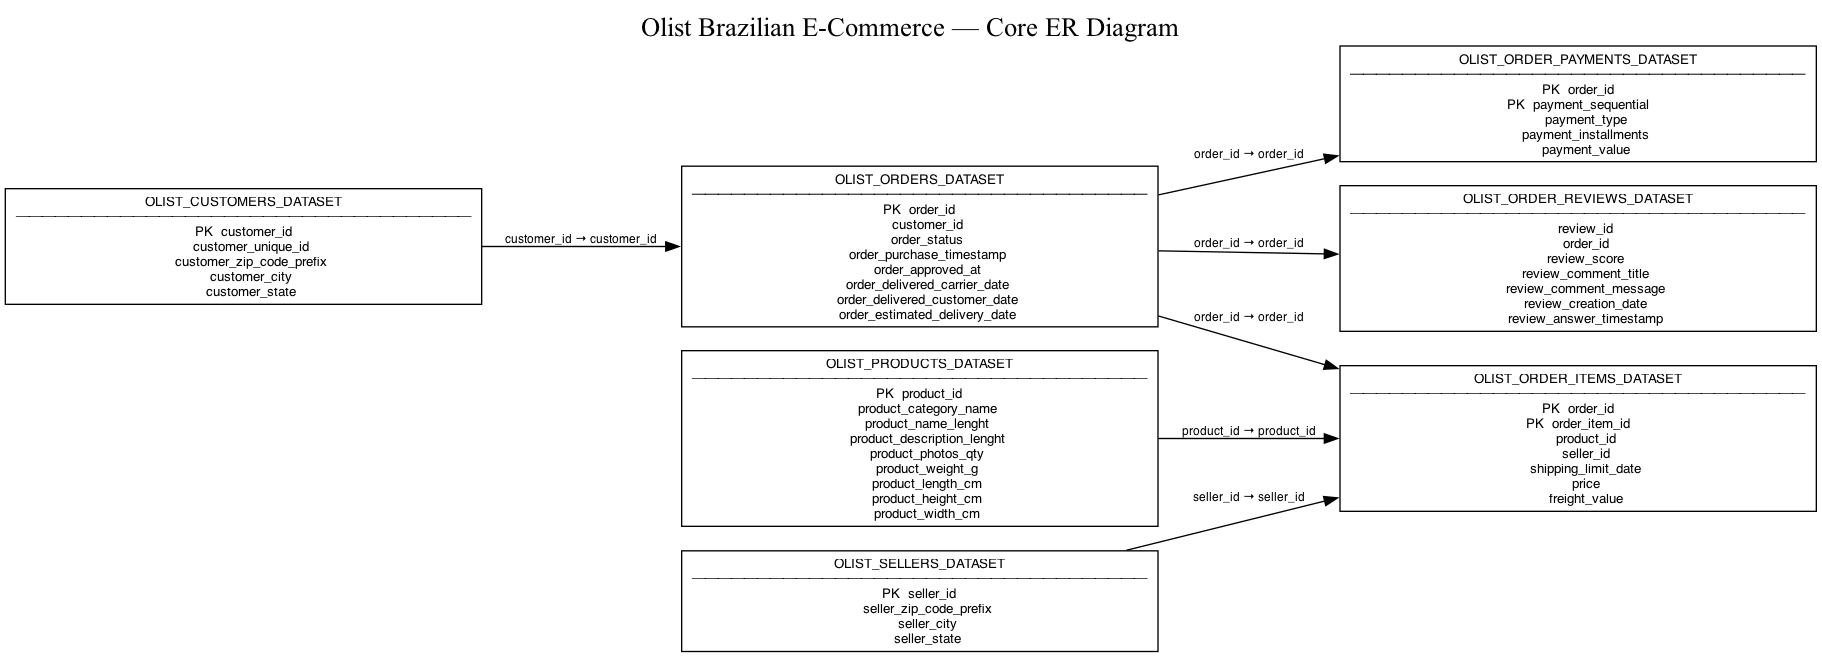

In [13]:
def format_table_label(table_name: str, df: pd.DataFrame) -> str:
    '''Create a readable Graphviz node label and mark detected primary keys.'''
    lines = [table_name.upper(), "─" * 35]
    lines.extend(
        f"{'PK  ' if column in confirmed_primary_keys.get(table_name, []) else '    '}{column}"
        for column in df.columns
    )
    return "\n".join(lines)


dot = Digraph("olist_er_diagram", format="png")
dot.attr(
    rankdir="LR",
    bgcolor="white",
    label="Olist Brazilian E-Commerce — Core ER Diagram",
    labelloc="t",
    fontsize="20",
)
dot.attr("node", shape="box", fontname="Helvetica", fontsize="10")
dot.attr("edge", fontname="Helvetica", fontsize="9")

for table_name in main_tables:
    dot.node(table_name, format_table_label(table_name, tables[table_name]))

for parent_table, parent_column, child_table, child_column in confirmed_relationships:
    dot.edge(parent_table, child_table, label=f"{parent_column} → {child_column}")

diagram_path = dot.render("olist_er_diagram", cleanup=True)
print(f"ER diagram written to: {diagram_path}")
display(Image(filename=diagram_path))


## 6. Generate a PostgreSQL DDL draft

This produces a *draft* schema from pandas types. Timestamp parsing, field lengths,
check constraints, and business-level constraints still need deliberate modelling before
production use. Only the explicitly confirmed keys from the preceding section are
included; detection results alone never become DDL constraints.


In [14]:
def postgres_type(series: pd.Series) -> str:
    '''Map common pandas dtypes to conservative PostgreSQL types.'''
    if pd.api.types.is_bool_dtype(series):
        return "BOOLEAN"
    if pd.api.types.is_integer_dtype(series):
        return "BIGINT"
    if pd.api.types.is_float_dtype(series):
        return "NUMERIC"
    if pd.api.types.is_datetime64_any_dtype(series):
        return "TIMESTAMP"
    return "TEXT"


def create_table_ddl(table_name: str, df: pd.DataFrame) -> str:
    '''Create readable PostgreSQL DDL with nullability and detected primary keys.'''
    definitions = []
    for column in df.columns:
        nullability = "NOT NULL" if df[column].notna().all() else "NULL"
        definitions.append(f'    "{column}" {postgres_type(df[column])} {nullability}')

    keys = confirmed_primary_keys.get(table_name, [])
    if keys:
        quoted_keys = ", ".join(f'"{key}"' for key in keys)
        definitions.append(f"    PRIMARY KEY ({quoted_keys})")

    return f'CREATE TABLE "{table_name}" (\n' + ",\n".join(definitions) + "\n);"


for table_name in main_tables:
    print(create_table_ddl(table_name, tables[table_name]))
    print()


CREATE TABLE "olist_customers_dataset" (
    "customer_id" TEXT NOT NULL,
    "customer_unique_id" TEXT NOT NULL,
    "customer_zip_code_prefix" BIGINT NOT NULL,
    "customer_city" TEXT NOT NULL,
    "customer_state" TEXT NOT NULL,
    PRIMARY KEY ("customer_id")
);

CREATE TABLE "olist_order_items_dataset" (
    "order_id" TEXT NOT NULL,
    "order_item_id" BIGINT NOT NULL,
    "product_id" TEXT NOT NULL,
    "seller_id" TEXT NOT NULL,
    "shipping_limit_date" TEXT NOT NULL,
    "price" NUMERIC NOT NULL,
    "freight_value" NUMERIC NOT NULL,
    PRIMARY KEY ("order_id", "order_item_id")
);

CREATE TABLE "olist_order_payments_dataset" (
    "order_id" TEXT NOT NULL,
    "payment_sequential" BIGINT NOT NULL,
    "payment_type" TEXT NOT NULL,
    "payment_installments" BIGINT NOT NULL,
    "payment_value" NUMERIC NOT NULL,
    PRIMARY KEY ("order_id", "payment_sequential")
);

CREATE TABLE "olist_order_reviews_dataset" (
    "review_id" TEXT NOT NULL,
    "order_id" TEXT NOT NULL,
    

## 7. validate a PostgreSQL load

This section assumes your database contains cleaned tables named `customers`, `orders`,
`order_items`, `products`, `sellers`, `order_payments`, and `order_reviews`. Leave
`CONNECT_TO_POSTGRES` as `False` to skip all database activity. Prefer a `DATABASE_URL`
environment variable so credentials are not stored in the notebook.


In [15]:
from sqlalchemy import create_engine, text

CONNECT_TO_POSTGRES = True
DATABASE_URL = "postgresql+psycopg2://ouahibaahmid@localhost:5432/olist_db"

engine = create_engine(DATABASE_URL, pool_pre_ping=True)

with engine.connect() as connection:
    database_version = connection.execute(text("SELECT version()")).scalar_one()

print(database_version)


PostgreSQL 15.18 (Homebrew) on aarch64-apple-darwin24.6.0, compiled by Apple clang version 17.0.0 (clang-1700.6.4.2), 64-bit


In [16]:
def run_sql(query: str) -> pd.DataFrame:
    '''Run a read-only query after the optional PostgreSQL connection has been enabled.'''
    if engine is None:
        raise RuntimeError("Enable CONNECT_TO_POSTGRES in the previous cell first.")
    return pd.read_sql(text(query), engine)


# Inspect the tables present in the target database.
if engine is None:
    print("Skipped: PostgreSQL validation is disabled.")
else:
    database_tables = run_sql('''
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    ''')
    display(database_tables)


,table_name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,orders
7,products
8,sellers


In [17]:
# Compare expected row counts after loading the seven core tables.
if engine is None:
    print("Skipped: PostgreSQL validation is disabled.")
else:
    row_counts = run_sql('''
        SELECT 'customers' AS table_name, COUNT(*) AS row_count FROM customers
        UNION ALL SELECT 'orders', COUNT(*) FROM orders
        UNION ALL SELECT 'order_items', COUNT(*) FROM order_items
        UNION ALL SELECT 'products', COUNT(*) FROM products
        UNION ALL SELECT 'sellers', COUNT(*) FROM sellers
        UNION ALL SELECT 'order_payments', COUNT(*) FROM order_payments
        UNION ALL SELECT 'order_reviews', COUNT(*) FROM order_reviews
        ORDER BY table_name;
    ''')
    display(row_counts)


,table_name,row_count
0,customers,99441
1,order_items,112650
2,order_payments,103886
3,order_reviews,99224
4,orders,99441
5,products,32951
6,sellers,3095


In [18]:
# Example business checks: customer distribution and join completeness.
if engine is None:
    print("Skipped: PostgreSQL validation is disabled.")
else:
    customer_states = run_sql('''
        SELECT customer_state, COUNT(*) AS customer_count
        FROM customers
        GROUP BY customer_state
        ORDER BY customer_count DESC;
    ''')
    display(customer_states)

    join_check = run_sql('''
        SELECT
            COUNT(*) AS orders_with_customer,
            COUNT(*) FILTER (WHERE c.customer_id IS NULL) AS orders_without_customer
        FROM orders AS o
        LEFT JOIN customers AS c ON c.customer_id = o.customer_id;
    ''')
    display(join_check)


,customer_state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


,orders_with_customer,orders_without_customer
0,99441,0
